# Modelo Support Vector Regression (SVR)

SVR con kernel RBF entrenado sobre las features adimensionales del reservorio. Para esta corrida concatenamos el **vector PVT del fluido** (Bo, Bg, Rs sobre 17 puntos de presión = 51 dimensiones) como features adicionales en cada fila, de manera que el modelo tenga acceso explícito a las propiedades termodinámicas del reservorio sobre el que está prediciendo.

Limitación esperada: SVR es un modelo no secuencial que trata cada timestep como muestra independiente. Dentro del train de Norne las 51 columnas del PVT son constantes (un único fluido Norne), así que el modelo no aprende a *usarlas* durante el entrenamiento. En la evaluación sobre Volve, esas columnas toman otros valores: el kernel RBF ve puntos en una región del espacio que nunca vio durante el train, y las predicciones tienden a degradarse. El experimento se incluye para completar el panorama metodológico (lineal, árboles, kernels, recurrente) y confirmar que la solución cross-reservoir requiere un modelo que pueda *consumir* el PVT como contexto, no solo recibirlo como input plano.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, GridSearchCV

## 2. Feature Engineering

Construimos las mismas 12 features adimensionales que usan los otros modelos clásicos (porosidad, log10 de la permeabilidad, presión inicial, fracciones de fluido recuperado/inyectado, ratios, etc). A diferencia de Ridge, RF y XGBoost, además **concatenamos el vector PVT del reservorio** (51 dimensiones) en cada fila.

In [2]:
M3_TO_BBL = 6.28981


def build_normalized_features(df: pd.DataFrame) -> pd.DataFrame:
    """Construye features adimensionales a partir del schema crudo del dataset.

    Conserva sim_id, reservoir_id y tiempo_dias como metadata.
    """
    out = pd.DataFrame(index=df.index)

    out["sim_id"] = df["sim_id"]
    out["tiempo_dias"] = df["tiempo_dias"]
    if "reservoir_id" in df.columns:
        out["reservoir_id"] = df["reservoir_id"]
        group_keys = ["reservoir_id", "sim_id"]
    else:
        group_keys = ["sim_id"]
    g = df.groupby(group_keys)

    pv_bbl = df["Area"] * df["Espesor_Neto_m"] * df["Porosidad"] * M3_TO_BBL

    out["Porosidad"] = df["Porosidad"]
    out["log10_Permeabilidad_mD"] = np.log10(df["Permeabilidad_mD"].clip(lower=1e-3))
    out["Presion_Burbuja_psi"] = df["Presion_Burbuja_psi"]

    out["Np_over_PV"] = df["Prod_Acumulada_Petroleo"] / pv_bbl
    out["Wp_over_PV"] = df["Prod_Acumulada_Agua"] / pv_bbl
    out["Winj_over_PV"] = df["Iny_Acumulada_Agua"] / pv_bbl

    with np.errstate(divide="ignore", invalid="ignore"):
        out["GOR_cum"] = np.where(
            df["Prod_Acumulada_Petroleo"] > 0,
            df["Prod_Acumulada_Gas"] / df["Prod_Acumulada_Petroleo"], 0.0)

    out["qo_over_PV"] = df["Caudal_Prod_Petroleo_bbl"] / pv_bbl
    out["qwinj_over_PV"] = df["Caudal_Iny_Agua_bbl"] / pv_bbl

    dt = g["tiempo_dias"].diff().replace(0, np.nan)
    wp_rate = g["Prod_Acumulada_Agua"].diff() / dt
    with np.errstate(divide="ignore", invalid="ignore"):
        out["WOR_inst"] = np.where(
            df["Caudal_Prod_Petroleo_bbl"] > 0,
            wp_rate / df["Caudal_Prod_Petroleo_bbl"], 0.0)

    total_liq = df["Prod_Acumulada_Petroleo"] + df["Prod_Acumulada_Agua"]
    with np.errstate(divide="ignore", invalid="ignore"):
        out["water_cut_cum"] = np.where(
            total_liq > 0, df["Prod_Acumulada_Agua"] / total_liq, 0.0)
        out["VRR_simple"] = np.where(
            total_liq > 0, df["Iny_Acumulada_Agua"] / total_liq, 0.0)

    out["Presion_Inicial"] = (
        df.groupby(group_keys)["Presion_Reservorio_psi"].transform("first"))

    out["Presion_Reservorio_psi"] = df["Presion_Reservorio_psi"]

    return out.fillna(0.0)


def build_pvt_vector(pvt_table_df: pd.DataFrame) -> np.ndarray:
    """Concatena [Bo · 17, Bg · 17 · 1000, Rs · 17 / 1000] en un vector de 51 dimensiones.

    El re-escalado lleva las tres curvas a órdenes de magnitud comparables
    (Bo ~ O(1), Bg sin escalar ~ O(1e-3), Rs sin escalar ~ O(1e3)).
    """
    bo = pvt_table_df["bo_rb_stb"].to_numpy()
    bg = pvt_table_df["bg_rb_scf"].to_numpy() * 1000.0
    rs = pvt_table_df["rs_scf_stb"].to_numpy() / 1000.0
    return np.concatenate([bo, bg, rs]).astype(np.float32)


def add_pvt_columns(features_df: pd.DataFrame, pvt_vector: np.ndarray) -> pd.DataFrame:
    """Agrega las 51 columnas del vector PVT (constantes por reservorio) al dataframe."""
    df = features_df.copy()
    for i, value in enumerate(pvt_vector):
        df[f"pvt_{i:02d}"] = value
    return df

## 3. Carga de datos

Cargamos los datasets crudos de Norne y Volve, las tablas PVT de laboratorio de ambos reservorios, construimos las features adimensionales y concatenamos el vector PVT correspondiente.

In [3]:
NORNE_URL = "https://raw.githubusercontent.com/ricomateo/opm-proof-of-concept/main/datasets/dataset_norne.csv"
VOLVE_URL = "https://raw.githubusercontent.com/ricomateo/opm-proof-of-concept/main/datasets/dataset_volve.csv"
PVT_NORNE_URL = "https://raw.githubusercontent.com/ricomateo/opm-proof-of-concept/main/datasets/pvt_norne.csv"
PVT_VOLVE_URL = "https://raw.githubusercontent.com/ricomateo/opm-proof-of-concept/main/datasets/pvt_volve.csv"

norne_raw = pd.read_csv(NORNE_URL)
volve_raw = pd.read_csv(VOLVE_URL)
norne_pvt = pd.read_csv(PVT_NORNE_URL)
volve_pvt = pd.read_csv(PVT_VOLVE_URL)

norne_features = build_normalized_features(norne_raw)
volve_features = build_normalized_features(volve_raw)

norne_pvt_vector = build_pvt_vector(norne_pvt)
volve_pvt_vector = build_pvt_vector(volve_pvt)

norne_df = add_pvt_columns(norne_features, norne_pvt_vector)
volve_df = add_pvt_columns(volve_features, volve_pvt_vector)

print(f"Norne: {len(norne_df):,} filas, {norne_df['sim_id'].nunique()} simulaciones")
print(f"Volve: {len(volve_df):,} filas, {volve_df['sim_id'].nunique()} simulaciones")
print(f"PVT vector dim: {len(norne_pvt_vector)}")

Norne: 10,580 filas, 30 simulaciones
Volve: 4,144 filas, 10 simulaciones
PVT vector dim: 51


## 4. Splits y normalización del target

Mismo protocolo que los otros modelos: 24 sims de Norne para train, 6 para test in-distribution, las 10 sims de Volve para evaluación cross-reservoir.

A diferencia de los modelos clásicos anteriores, acá aplicamos la **misma normalización del target que usa el LSTM**: en lugar de predecir directamente la presión absoluta (en el orden de 3000-5000 psi), el modelo predice un delta normalizado:

$$\Delta P_{norm} = \frac{P_r - P_{init}}{5000}$$

donde $P_{init}$ es la presión inicial del reservorio (constante por simulación) y 5000 psi es una escala fija. Al evaluar, volvemos a la escala original mediante:

$$P_r = P_{init} + \Delta P_{norm} \cdot 5000$$

Esto desacopla la predicción del punto de partida particular de cada corrida, y le da al modelo un target chico y centrado cerca de cero, más estable para el entrenamiento.

In [4]:
TRAIN_SIMS = list(range(1, 25))   # sims 1..24 de Norne (24 sims)
TEST_SIMS = list(range(25, 31))   # sims 25..30 de Norne (6 sims)

PRESSURE_SCALE = 5000.0

feature_cols = [c for c in norne_df.columns
                if c not in ["sim_id", "reservoir_id", "tiempo_dias",
                             "Presion_Reservorio_psi"]]
target_col = "Presion_Reservorio_psi"

df_train = norne_df[norne_df["sim_id"].isin(TRAIN_SIMS)].reset_index(drop=True)
df_test = norne_df[norne_df["sim_id"].isin(TEST_SIMS)].reset_index(drop=True)
df_volve = volve_df.reset_index(drop=True)

X_train = df_train[feature_cols]
y_train = df_train[target_col]
groups_train = df_train["sim_id"]

X_test = df_test[feature_cols]
y_test = df_test[target_col]

X_volve = df_volve[feature_cols]
y_volve = df_volve[target_col]

# Target normalizado: delta de presion respecto del valor inicial, dividido por la escala fija.
# El modelo se entrena para predecir este delta normalizado. Al evaluar, denormalizamos
# multiplicando por PRESSURE_SCALE y sumando la presion inicial.
y_train_delta = (y_train - df_train["Presion_Inicial"]) / PRESSURE_SCALE

print(f"Train: {len(X_train):,} filas | Test (Norne): {len(X_test):,} filas | "
      f"Cross-reservoir (Volve): {len(X_volve):,} filas")
print(f"Total features: {len(feature_cols)} (12 base + 51 PVT)")
print(f"Target delta normalizado: media={y_train_delta.mean():.4f}, "
      f"std={y_train_delta.std():.4f}, min={y_train_delta.min():.4f}, "
      f"max={y_train_delta.max():.4f}")

Train: 8,444 filas | Test (Norne): 2,136 filas | Cross-reservoir (Volve): 4,144 filas
Total features: 64 (12 base + 51 PVT)
Target delta normalizado: media=-0.0422, std=0.0421, min=-0.1142, max=0.0696


## 5. Funciones de plot y evaluación

In [5]:
def plot_trayectoria(tiempo_dias, y_true, y_pred, titulo, nombre_archivo=None):
    """Plot único con la trayectoria de presión de una sola simulación."""
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(tiempo_dias, y_true, color="black", lw=1.6, label="Presión real")
    ax.plot(tiempo_dias, y_pred, color="C0", lw=1.4, linestyle="--",
            label="Presión predicha")
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    ax.set_xlabel("Tiempo desde el comienzo de la producción en días")
    ax.set_ylabel("Presión (psi)")
    ax.set_title(f"{titulo} (R² = {r2:.3f}, MAE = {mae:.1f} psi)")
    ax.grid(alpha=0.3)
    ax.legend(loc="best")
    plt.tight_layout()
    if nombre_archivo is not None:
        plt.savefig(nombre_archivo, dpi=150, bbox_inches="tight")
    plt.show()


def plot_parity(y_true, y_pred, titulo, nombre_archivo=None):
    """Scatter de presión real vs predicha, con la diagonal y = x de referencia."""
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(y_true, y_pred, s=6, alpha=0.4, color="C0")
    lo = min(float(np.min(y_true)), float(np.min(y_pred)))
    hi = max(float(np.max(y_true)), float(np.max(y_pred)))
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="y = x")
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    ax.set_xlabel("Presión real (psi)")
    ax.set_ylabel("Presión predicha (psi)")
    ax.set_title(f"{titulo} (R² = {r2:.3f}, MAE = {mae:.1f} psi)")
    ax.grid(alpha=0.3)
    ax.legend(loc="best")
    plt.tight_layout()
    if nombre_archivo is not None:
        plt.savefig(nombre_archivo, dpi=150, bbox_inches="tight")
    plt.show()

In [6]:
def evaluar(model, df_features, df_target, df_full, sim_ids, nombre):
    """Predice por simulacion y devuelve metricas + listas para plotear.

    El modelo predice el delta normalizado (P_r - P_init) / PRESSURE_SCALE.
    Aca lo denormalizamos a presion absoluta antes de calcular metricas y plotear:
        P_r_predicha = P_init + delta_pred * PRESSURE_SCALE
    """
    y_true_por_sim = []
    y_pred_por_sim = []
    tiempo_por_sim = []
    for sim_id in sim_ids:
        mask = df_full["sim_id"] == sim_id
        X_sim = df_features[mask]
        y_sim = df_target[mask].to_numpy()
        tiempo_sim = df_full.loc[mask, "tiempo_dias"].to_numpy()
        p_init_sim = df_full.loc[mask, "Presion_Inicial"].to_numpy()
        delta_pred = model.predict(X_sim)
        y_pred = p_init_sim + delta_pred * PRESSURE_SCALE
        y_true_por_sim.append(y_sim)
        y_pred_por_sim.append(y_pred)
        tiempo_por_sim.append(tiempo_sim)

    y_true_flat = np.concatenate(y_true_por_sim)
    y_pred_flat = np.concatenate(y_pred_por_sim)
    r2 = r2_score(y_true_flat, y_pred_flat)
    mae = mean_absolute_error(y_true_flat, y_pred_flat)
    rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))

    print(f"=== {nombre} ===")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAE:  {mae:.2f} psi")
    print(f"  RMSE: {rmse:.2f} psi")
    return {
        "y_true_por_sim": y_true_por_sim,
        "y_pred_por_sim": y_pred_por_sim,
        "tiempo_por_sim": tiempo_por_sim,
        "y_true_flat": y_true_flat,
        "y_pred_flat": y_pred_flat,
    }

## 6. Entrenamiento

SVR con kernel RBF, envuelto en un `Pipeline` con `StandardScaler` (el SVR requiere features escaladas para que el kernel funcione bien). Buscamos hiperparámetros con `GridSearchCV` sobre 5 folds de `GroupKFold` (cada fold contiene simulaciones completas).

Grid acotado para que el experimento sea tratable: SVR escala como O(n²-n³) con el tamaño del dataset, y acá tenemos ~8400 filas × 63 features.

In [7]:
gkf = GroupKFold(n_splits=5)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf")),
])

# Epsilon mas chico porque el target normalizado vive en un rango chico (~ -0.5 a 0.1).
param_grid = {
    "svr__C":       [1.0, 10.0, 100.0],
    "svr__gamma":   ["scale", "auto"],
    "svr__epsilon": [0.01],
}

gs = GridSearchCV(
    pipeline,
    param_grid,
    cv=gkf,
    scoring="r2",
    n_jobs=-1,
    verbose=1,
    refit=True,
)
gs.fit(X_train, y_train_delta, groups=groups_train)

print(f"\nMejores hiperparámetros: {gs.best_params_}")
print(f"Mejor R² en CV (sobre delta normalizado): {gs.best_score_:.4f}")

modelo_final = gs.best_estimator_

Fitting 5 folds for each of 6 candidates, totalling 30 fits



Mejores hiperparámetros: {'svr__C': 1.0, 'svr__epsilon': 0.01, 'svr__gamma': 'auto'}
Mejor R² en CV (sobre delta normalizado): 0.9847


## 7. Evaluación in-distribution sobre Norne test

El modelo se evalúa sobre las 6 simulaciones de Norne que no vio durante el entrenamiento.

In [8]:
resultados_norne = evaluar(
    modelo_final, X_test, y_test, df_test, TEST_SIMS,
    nombre="Norne test (in-distribution)"
)

=== Norne test (in-distribution) ===
  R²:   0.9877
  MAE:  20.17 psi
  RMSE: 25.48 psi


Trayectoria de presión sobre una simulación representativa del set de test (la primera, sim 25).

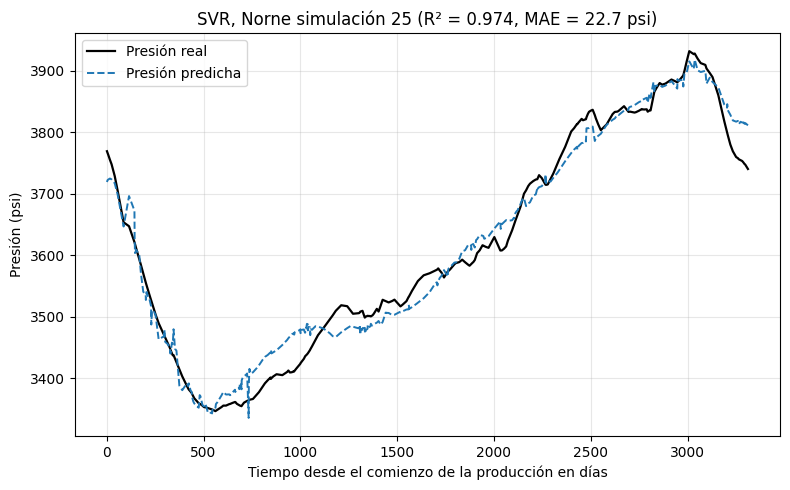

In [9]:
SIM_NORNE = TEST_SIMS[0]  # sim 25
idx = TEST_SIMS.index(SIM_NORNE)
plot_trayectoria(
    resultados_norne["tiempo_por_sim"][idx],
    resultados_norne["y_true_por_sim"][idx],
    resultados_norne["y_pred_por_sim"][idx],
    titulo=f"SVR, Norne simulación {SIM_NORNE}",
    nombre_archivo="svr_norne_trayectoria.png",
)

Parity plot global con todos los timesteps de las 6 simulaciones de test.

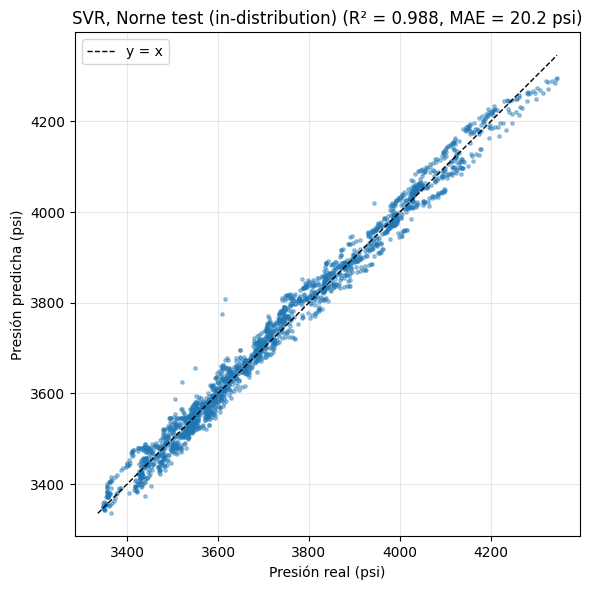

In [10]:
plot_parity(
    resultados_norne["y_true_flat"], resultados_norne["y_pred_flat"],
    titulo="SVR, Norne test (in-distribution)",
    nombre_archivo="svr_norne_parity.png",
)

## 8. Evaluación cross-reservoir sobre Volve

El modelo nunca vio Volve durante el entrenamiento. En esta evaluación las 51 columnas del PVT toman los valores del laboratorio de Volve (distintos de los de Norne).

In [11]:
VOLVE_SIMS = sorted(df_volve["sim_id"].unique().tolist())
print(f"Volve sims: {VOLVE_SIMS}")

Volve sims: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [12]:
resultados_volve = evaluar(
    modelo_final, X_volve, y_volve, df_volve, VOLVE_SIMS,
    nombre="Volve (cross-reservoir)"
)

=== Volve (cross-reservoir) ===
  R²:   0.3811
  MAE:  154.68 psi
  RMSE: 215.11 psi


Trayectoria de presión sobre una simulación de Volve (la primera, sim 1).

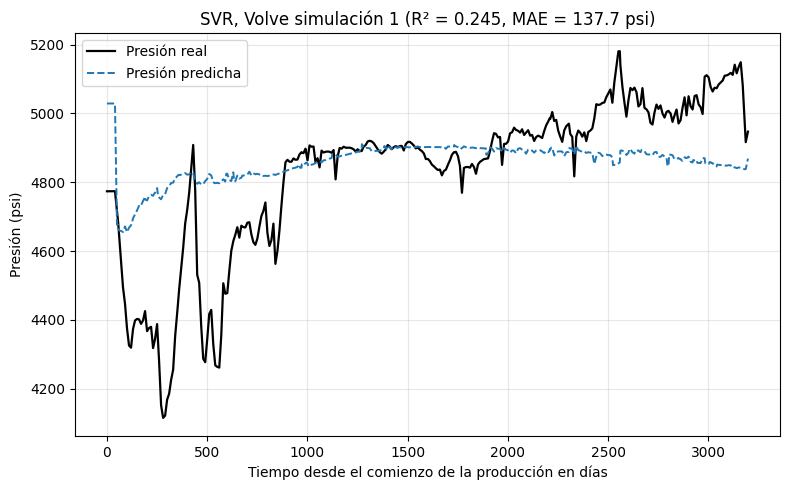

In [13]:
SIM_VOLVE = VOLVE_SIMS[0]  # sim 1
idx = VOLVE_SIMS.index(SIM_VOLVE)
plot_trayectoria(
    resultados_volve["tiempo_por_sim"][idx],
    resultados_volve["y_true_por_sim"][idx],
    resultados_volve["y_pred_por_sim"][idx],
    titulo=f"SVR, Volve simulación {SIM_VOLVE}",
    nombre_archivo="svr_volve_trayectoria.png",
)

Parity plot global con todos los timesteps de las 10 simulaciones de Volve.

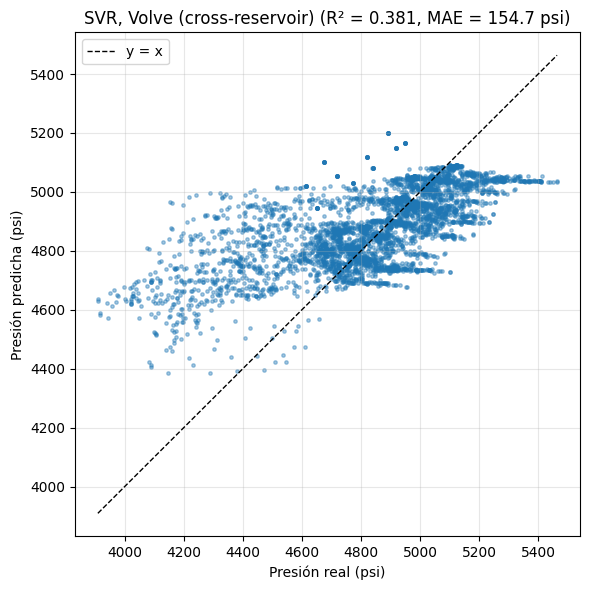

In [14]:
plot_parity(
    resultados_volve["y_true_flat"], resultados_volve["y_pred_flat"],
    titulo="SVR, Volve (cross-reservoir)",
    nombre_archivo="svr_volve_parity.png",
)